# Question 1 : Multi-Task CNN on Fashion-MNIST

### Imports and Setup

In [17]:
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import FashionMNIST
from IPython.display import display, Markdown
import os
# os.environ['WANDB_CONSOLE'] = 'off'
# os.environ['WANDB_DISABLE_CODE'] = 'true'
# os.environ['WANDB_SILENT'] = 'true'
import wandb
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, mean_absolute_error, mean_squared_error, f1_score
from typing import Tuple, Dict, List
from datetime import datetime
import pandas as pd
from tqdm import tqdm

# Configuration
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

# Some preliminary code
def add_username(username) -> None:
    plt.text(0.95, 0.95, username, ha="right", va="top", transform=plt.gca().transAxes, fontsize=10, color="gray", alpha=0.7)

def print_separator() -> None:
    print("="*50)

Using device: cuda


In [18]:
# Print the cuda device name
if torch.cuda.is_available():
    print(f"CUDA Device Name: {torch.cuda.get_device_name(0)}")
    print(f"Available GPUs: {torch.cuda.device_count()}")

CUDA Device Name: NVIDIA GeForce RTX 3050 Laptop GPU
Available GPUs: 1


### Dataset Class

In [19]:
class FashionMNISTDataset(Dataset):
    """
    Custom Dataset class for Fashion-MNIST with classification and regression targets.
    
    Returns:
        image: normalized tensor [1, 28, 28]
        class_label: integer label in {0, ..., 9}
        ink_target: normalized pixel intensity (average pixel value)
    """

    def __init__(self, data, targets, transform=None, mean=None, std=None):
        """
        Initialize the dataset.
        
        Args:
            data: Image data
            targets: Classification labels
            transform: Data augmentation transforms
        """
        self.data = data
        self.targets = targets
        self.transform = transform
        
        if mean is None or std is None:
            raise ValueError("mean and std must be provided for normalization")

        self.mean = mean
        self.std = std
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get image and label
        image = self.data[idx]
        class_label = self.targets[idx]
        
        # Convert to PIL Image for transforms
        image_pil = transforms.ToPILImage()(image)
        
        # Calculate ink target
        image_np = np.array(image_pil).astype(np.float32) / 255.0
        ink_target = float(np.mean(image_np))
        
        # Apply transforms if any
        if self.transform:
            image_tensor = self.transform(image_pil)
        else:
            # Default: just convert to tensor and normalize
            image_tensor = transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[self.mean], std=[self.std])
            ])(image_pil)
        
        class_label = int(class_label)
        ink_target = np.float32(ink_target)
        
        return image_tensor, class_label, ink_target

def calculate_mean_std(data):
    """
    Calculate mean and std of the dataset.
    
    Args:
        data: Tensor of images [N, H, W]
    
    Returns:
        mean, std
    """
    # Convert to float and normalize to [0, 1]
    data_float = data.float() / 255.0
    
    # Calculate mean and std across all pixels
    mean = data_float.mean().item()
    std = data_float.std().item()
    
    return mean, std


def load_fashion_data(batch_size=64, train_val_split=0.9):
    """
    Load Fashion-MNIST dataset and create train/val/test splits.
    
    Args:
        batch_size: Batch size for dataloaders
        train_val_split: Ratio for train/val split (default 90/10)
    
    Returns:
        train_loader, val_loader, test_loader
    """
    # Download raw Fashion-MNIST data
    train_data_raw = FashionMNIST(root='./data', train=True, download=True)
    test_data_raw = FashionMNIST(root='./data', train=False, download=True)
    
    # Extract data and targets
    train_images = train_data_raw.data
    train_labels = train_data_raw.targets
    test_images = test_data_raw.data
    test_labels = test_data_raw.targets

    print_separator()
    print("Calculating dataset statistics")
    mean, std = calculate_mean_std(train_images)
    print(f"Dataset mean: {mean:.4f}, std: {std:.4f}")
    print_separator()
    
    # Split train into train and validation
    total_train = len(train_images)
    train_size = int(train_val_split * total_train)
    val_size = total_train - train_size
    
    indices = torch.randperm(total_train).tolist()
    train_indices = indices[:train_size]
    val_indices = indices[train_size:]
    
    train_images_split = train_images[train_indices]
    train_labels_split = train_labels[train_indices]
    val_images_split = train_images[val_indices]
    val_labels_split = train_labels[val_indices]
    
    # Define augmentations for training
    train_transform = transforms.Compose([
        transforms.RandomCrop(28, padding=2),  # Random crop with padding
        transforms.RandomRotation(10),  # Small rotation
        transforms.ToTensor(),
        transforms.Normalize(mean=[mean], std=[std])
    ])
    
    # No augmentation for validation and test
    eval_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[mean], std=[std])
    ])
    
    # Create datasets
    train_dataset = FashionMNISTDataset(train_images_split, train_labels_split, transform=train_transform, mean=mean, std=std)
    val_dataset = FashionMNISTDataset(val_images_split, val_labels_split, transform=eval_transform, mean=mean, std=std)
    test_dataset = FashionMNISTDataset(test_images, test_labels, transform=eval_transform, mean=mean, std=std)

    # Create dataloaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=torch.cuda.is_available())

    print(f"Train size: {len(train_dataset)}")
    print(f"Validation size: {len(val_dataset)}")
    print(f"Test size: {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader

### Model Architecture

In [20]:
class MultiTaskCNN(nn.Module):
    """
    Multi-task CNN for Fashion-MNIST classification and ink regression.
    
    Architecture:
    - Shared convolutional backbone (2-3 Conv-BatchNorm-ReLU-Pool blocks with dropout)
    - Classification head: outputs logits [B, 10]
    - Regression head: outputs scalar values [B, 1]
    """
    
    def __init__(self, num_classes=10, dropout_rate=0.3, num_filters=32):
        """
        Initialize the multi-task CNN.
        
        Args:
            num_classes: Number of output classes (10 for Fashion-MNIST)
            dropout_rate: Dropout probability
            num_filters: Base number of filters in first conv layer
        """
        super().__init__()
        
        # Shared convolutional backbone
        # Block 1: [B, 1, 28, 28] -> [B, num_filters, 14, 14]
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, num_filters, kernel_size=3, padding=1), # [IC, OC, ...],
            nn.BatchNorm2d(num_filters),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        # Block 2: [B, num_filters, 14, 14] -> [B, num_filters*2, 7, 7]
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(num_filters, num_filters*2, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_filters*2),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        # Block 3: [B, num_filters*2, 7, 7] -> [B, num_filters*4, 3, 3]
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(num_filters*2, num_filters*4, kernel_size=3, padding=1),
            nn.BatchNorm2d(num_filters*4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        
        # Calculate flattened size: num_filters*4 * 3 * 3
        flattened_size = num_filters * 4 * 3 * 3
        
        # Classification head
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes)
        )
        
        # Regression head
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_size, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )
        
        # Store intermediate outputs for visualization
        self.intermediate_outputs = {}
    
    def forward(self, x, return_features=False):
        """
        Forward pass through the network.
        
        Args:
            x: Input tensor [B, 1, 28, 28]
            return_features: If True, return intermediate feature maps
        
        Returns:
            classification_logits: [B, 10]
            regression_output: [B, 1]
            features (optional): dict of intermediate feature maps
        """
        # Shared backbone
        x1 = self.conv_block1(x)
        x2 = self.conv_block2(x1)
        x3 = self.conv_block3(x2)
        
        # Store intermediate outputs
        if return_features:
            self.intermediate_outputs = {
                'conv_block1': x1.detach().cpu(),
                'conv_block2': x2.detach().cpu(),
                'conv_block3': x3.detach().cpu()
            }
        
        # Task-specific heads
        classification_logits = self.classifier(x3)
        regression_output = self.regressor(x3)
        
        if return_features:
            return classification_logits, regression_output, self.intermediate_outputs
        
        return classification_logits, regression_output


def joint_loss(class_logits, class_targets, reg_outputs, reg_targets, 
               lambda1=1.0, lambda2=1.0):
    """
    Compute joint loss for multi-task learning.
    
    L_total = λ1 * L_CE + λ2 * L_MSE
    
    Args:
        class_logits: Classification logits [B, 10]
        class_targets: True class labels [B]
        reg_outputs: Regression predictions [B, 1]
        reg_targets: True ink values [B]
        lambda1: Weight for classification loss
        lambda2: Weight for regression loss
    
    Returns:
        total_loss, ce_loss, mse_loss
    """
    ce_loss = nn.CrossEntropyLoss()(class_logits, class_targets)
    mse_loss = nn.MSELoss()(reg_outputs.squeeze(), reg_targets)
    
    total_loss = lambda1 * ce_loss + lambda2 * mse_loss
    
    return total_loss, ce_loss, mse_loss

### Train and Evaluate

In [21]:
def train_epoch(model, train_loader, optimizer, lambda1, lambda2, device, show_progress=False):
    """
    Train for one epoch.
    
    Returns:
        Dictionary with training metrics
    """
    model.train()
    
    total_loss = 0.0
    total_ce_loss = 0.0
    total_mse_loss = 0.0
    all_preds = []
    all_targets = []
    all_reg_preds = []
    all_reg_targets = []

    # Only show progress bar if requested
    iterator = tqdm(train_loader, desc='Training', leave=False) if show_progress else train_loader
    
    for images, class_labels, ink_targets in iterator:
        images = images.to(device)
        class_labels = class_labels.to(device)
        ink_targets = ink_targets.to(device)
        
        # Forward pass
        class_logits, reg_outputs = model(images)
        
        # Compute loss
        loss, ce_loss, mse_loss = joint_loss(
            class_logits, class_labels, reg_outputs, ink_targets,
            lambda1, lambda2
        )
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Accumulate metrics
        total_loss += loss.item() * images.size(0)
        total_ce_loss += ce_loss.item() * images.size(0)
        total_mse_loss += mse_loss.item() * images.size(0)
        
        # Store predictions
        preds = torch.argmax(class_logits, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(class_labels.cpu().numpy())
        all_reg_preds.extend(reg_outputs.squeeze().detach().cpu().numpy())
        all_reg_targets.extend(ink_targets.cpu().numpy())

        # Update progress bar if shown
        if show_progress:
            iterator.set_postfix({'loss': f'{loss.item():.4f}'})
    
    # Calculate metrics
    n_samples = len(train_loader.dataset)
    metrics = {
        'loss': total_loss / n_samples,
        'ce_loss': total_ce_loss / n_samples,
        'mse_loss': total_mse_loss / n_samples,
        'accuracy': accuracy_score(all_targets, all_preds),
        'f1_score': f1_score(all_targets, all_preds, average='weighted'),
        'mae': mean_absolute_error(all_reg_targets, all_reg_preds),
        'rmse': np.sqrt(mean_squared_error(all_reg_targets, all_reg_preds))
    }
    
    return metrics


def evaluate(model, data_loader, lambda1, lambda2, device, show_progress=False):
    """
    Evaluate model on validation or test set.
    
    Returns:
        Dictionary with evaluation metrics
    """
    model.eval()
    
    total_loss = 0.0
    total_ce_loss = 0.0
    total_mse_loss = 0.0
    all_preds = []
    all_targets = []
    all_reg_preds = []
    all_reg_targets = []

    # Only show progress bar if requested
    iterator = tqdm(data_loader, desc='Validation', leave=False) if show_progress else data_loader
    
    with torch.no_grad():
        for images, class_labels, ink_targets in iterator:
            images = images.to(device)
            class_labels = class_labels.to(device)
            ink_targets = torch.tensor(ink_targets, dtype=torch.float32).to(device)
            
            # Forward pass
            class_logits, reg_outputs = model(images)
            
            # Compute loss
            loss, ce_loss, mse_loss = joint_loss(
                class_logits, class_labels, reg_outputs, ink_targets,
                lambda1, lambda2
            )
            
            # Accumulate metrics
            total_loss += loss.item() * images.size(0)
            total_ce_loss += ce_loss.item() * images.size(0)
            total_mse_loss += mse_loss.item() * images.size(0)
            
            # Store predictions
            preds = torch.argmax(class_logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(class_labels.cpu().numpy())
            all_reg_preds.extend(reg_outputs.squeeze().cpu().numpy())
            all_reg_targets.extend(ink_targets.cpu().numpy())
    
    # Calculate metrics
    n_samples = len(data_loader.dataset)
    metrics = {
        'loss': total_loss / n_samples,
        'ce_loss': total_ce_loss / n_samples,
        'mse_loss': total_mse_loss / n_samples,
        'accuracy': accuracy_score(all_targets, all_preds),
        'f1_score': f1_score(all_targets, all_preds, average='weighted'),
        'mae': mean_absolute_error(all_reg_targets, all_reg_preds),
        'rmse': np.sqrt(mean_squared_error(all_reg_targets, all_reg_preds))
    }
    
    return metrics


def train_model(model, train_loader, val_loader, config, device):
    """
    Complete training loop with wandb logging.
    
    Args:
        model: MultiTaskCNN model
        train_loader: Training data loader
        val_loader: Validation data loader
        config: Dictionary with hyperparameters
        device: Device to train on
    
    Returns:
        Trained model and training history
    """
    # Initialize optimizer
    # weight_decay is the L2 regularization strength
    if config['optimizer'] == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=config['lr'], momentum=0.9, weight_decay=1e-4)
    elif config['optimizer'] == 'Adam': #(Adaptive Moment Estimation) - Uses adaptive LR
        optimizer = optim.Adam(model.parameters(), lr=config['lr'], weight_decay=1e-4)
    elif config['optimizer'] == 'AdamW': #(Adam with a more effective Weight Decay)
        optimizer = optim.AdamW(model.parameters(), lr=config['lr'], weight_decay=1e-4)
    
    # Learning rate scheduler - acts at a global scale unlike Adam which acts at a per-parameter level
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

    best_val_loss = float('inf')
    best_val_acc = 0.0
    best_val_rmse = float('inf')
    history = {
        'train_loss': [], 'train_ce': [], 'train_mse': [], 'train_acc': [], 
        'train_mae': [], 'train_rmse': [], 'train_f1': [],
        'val_loss': [], 'val_ce': [], 'val_mse': [], 'val_acc': [], 
        'val_mae': [], 'val_rmse': [], 'val_f1': []
    }
    
    # Progress bar for epochs
    epoch_pbar = tqdm(range(config['epochs']), desc=f"Training {config.get('name', 'model')}")
    
    for epoch in epoch_pbar:
        # Train
        train_metrics = train_epoch(model, train_loader, optimizer, config['lambda1'], config['lambda2'], device)
        
        # Validate
        val_metrics = evaluate(model, val_loader, config['lambda1'], config['lambda2'], device)

        # Update scheduler
        scheduler.step(val_metrics['loss'])
        
        # Store history
        history['train_loss'].append(train_metrics['loss'])
        history['train_ce'].append(train_metrics['ce_loss'])
        history['train_mse'].append(train_metrics['mse_loss'])
        history['train_acc'].append(train_metrics['accuracy'])
        history['train_mae'].append(train_metrics['mae'])
        history['train_rmse'].append(train_metrics['rmse'])
        history['train_f1'].append(train_metrics['f1_score'])

        history['val_loss'].append(val_metrics['loss'])
        history['val_ce'].append(val_metrics['ce_loss'])
        history['val_mse'].append(val_metrics['mse_loss'])
        history['val_acc'].append(val_metrics['accuracy'])
        history['val_mae'].append(val_metrics['mae'])
        history['val_rmse'].append(val_metrics['rmse'])
        history['val_f1'].append(val_metrics['f1_score'])
        
        # Log to wandb
        wandb.log({
            'epoch': epoch + 1,
            'train/loss': train_metrics['loss'],
            'train/ce_loss': train_metrics['ce_loss'],
            'train/mse_loss': train_metrics['mse_loss'],
            'train/accuracy': train_metrics['accuracy'],
            'train/mae': train_metrics['mae'],
            'train/rmse': train_metrics['rmse'],
            'train/f1_score': train_metrics['f1_score'],
            'val/loss': val_metrics['loss'],
            'val/ce_loss': val_metrics['ce_loss'],
            'val/mse_loss': val_metrics['mse_loss'],
            'val/accuracy': val_metrics['accuracy'],
            'val/mae': val_metrics['mae'],
            'val/rmse': val_metrics['rmse'],
            'val/f1_score': val_metrics['f1_score'],
            'learning_rate': optimizer.param_groups[0]['lr']
        })
        
        # Track best models
        if val_metrics['accuracy'] > best_val_acc:
            best_val_acc = val_metrics['accuracy']
        if val_metrics['rmse'] < best_val_rmse:
            best_val_rmse = val_metrics['rmse']
        
        # Update epoch progress bar with metrics
        epoch_pbar.set_postfix({
            'train_acc': f"{train_metrics['accuracy']:.3f}",
            'val_acc': f"{val_metrics['accuracy']:.3f}",
            'train_rmse': f"{train_metrics['rmse']:.3f}",
            'val_rmse': f"{val_metrics['rmse']:.3f}",
            'lr': f"{optimizer.param_groups[0]['lr']:.6f}"
        })
    
    # Print final summary
    print(f"\nTraining complete!")
    print(f"  Best Val Accuracy: {best_val_acc:.4f}")
    print(f"  Best Val RMSE: {best_val_rmse:.4f}")

    return model, history

### Visualizations

In [22]:
def visualize_feature_maps(model, test_loader, device, num_images=3, model_name="best_model"):
    """
    Visualize intermediate feature maps for test images.
    
    Args:
        model: Trained model
        test_loader: Test data loader
        device: Device
        num_images: Number of test images to visualize
        model_name: Name of the model for logging
    """
    model.eval()
    
    # Get a batch of test images
    images, labels, _ = next(iter(test_loader))
    images = images[:num_images].to(device)
    
    # Get feature maps
    with torch.no_grad():
        _, _, features = model(images, return_features=True)
    
    # Create figure
    fig, axes = plt.subplots(num_images, 4, figsize=(16, 4*num_images))
    
    class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
                   'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
    
    for img_idx in range(num_images):
        # Original image
        img = images[img_idx].cpu().squeeze()
        img = (img * 0.3530) + 0.2860  # Denormalize
        axes[img_idx, 0].imshow(img, cmap='gray')
        axes[img_idx, 0].set_title(f'Original: {class_names[labels[img_idx]]}')
        axes[img_idx, 0].axis('off')
        
        # Feature maps from each conv block
        for block_idx, block_name in enumerate(['conv_block1', 'conv_block2', 'conv_block3']):
            feature_map = features[block_name][img_idx]
            
            # Average across all channels
            avg_feature = torch.mean(feature_map, dim=0).numpy()
            
            axes[img_idx, block_idx+1].imshow(avg_feature, cmap='viridis')
            axes[img_idx, block_idx+1].set_title(f'{block_name}')
            axes[img_idx, block_idx+1].axis('off')
    
    plt.tight_layout()
    add_username("siddarth.g")
    
    plt.show()
    plt.close()
    
    print("\n=== Feature Map Interpretation ===")
    print("Conv Block 1 (Early layers):")
    print("  - Captures low-level features: edges, corners, simple textures")
    print("  - Detects basic shapes and contours of clothing items")
    print("  - Responds to intensity gradients important for ink regression")
    
    print("\nConv Block 2 (Middle layers):")
    print("  - Combines edges into more complex patterns")
    print("  - Detects clothing-specific textures (fabric patterns, stitching)")
    print("  - Begins to recognize parts of garments (collars, sleeves, straps)")
    
    print("\nConv Block 3 (Deep layers):")
    print("  - Captures high-level semantic features")
    print("  - Recognizes specific clothing regions and overall garment structure")
    print("  - Provides abstract representations useful for both classification and ink prediction")
    print("  - Helps distinguish between similar categories (shirts vs. t-shirts)")



def plot_training_curves(history, title_suffix=""):
    """
    Plot training and validation curves.
    
    Args:
        history: Dictionary with training history
        title_suffix: Additional text for title
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Total loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Total Loss')
    axes[0, 0].set_title(f'Total Loss {title_suffix}')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Classification loss
    axes[0, 1].plot(epochs, history['train_ce'], 'b-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs, history['val_ce'], 'r-', label='Validation', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('CE Loss')
    axes[0, 1].set_title(f'Classification Loss (CE) {title_suffix}')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Regression loss
    axes[0, 2].plot(epochs, history['train_mse'], 'b-', label='Train', linewidth=2)
    axes[0, 2].plot(epochs, history['val_mse'], 'r-', label='Validation', linewidth=2)
    axes[0, 2].set_xlabel('Epoch')
    axes[0, 2].set_ylabel('MSE Loss')
    axes[0, 2].set_title(f'Regression Loss (MSE) {title_suffix}')
    axes[0, 2].legend()
    axes[0, 2].grid(True, alpha=0.3)
    
    # Accuracy
    axes[1, 0].plot(epochs, history['train_acc'], 'b-', label='Train', linewidth=2)
    axes[1, 0].plot(epochs, history['val_acc'], 'r-', label='Validation', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('Accuracy')
    axes[1, 0].set_title(f'Classification Accuracy {title_suffix}')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # MAE
    axes[1, 1].plot(epochs, history['train_mae'], 'b-', label='Train', linewidth=2)
    axes[1, 1].plot(epochs, history['val_mae'], 'r-', label='Validation', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('MAE')
    axes[1, 1].set_title(f'Regression MAE {title_suffix}')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    # RMSE
    axes[1, 2].plot(epochs, history['train_rmse'], 'b-', label='Train', linewidth=2)
    axes[1, 2].plot(epochs, history['val_rmse'], 'r-', label='Validation', linewidth=2)
    axes[1, 2].set_xlabel('Epoch')
    axes[1, 2].set_ylabel('RMSE')
    axes[1, 2].set_title(f'Regression RMSE {title_suffix}')
    axes[1, 2].legend()
    axes[1, 2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    add_username("siddarth.g")
    
    wandb.log({f"training_curves_{title_suffix}": wandb.Image(fig)})
    plt.show()
    plt.close()

### Function Calls

In [23]:
# Load Fashion-MNIST data
print("Loading Fashion-MNIST dataset...")
train_loader, val_loader, test_loader = load_fashion_data(batch_size=64, train_val_split=0.9)
print("Data loaded successfully!\n")

Loading Fashion-MNIST dataset...
Calculating dataset statistics
Dataset mean: 0.2860, std: 0.3530
Train size: 54000
Validation size: 6000
Test size: 10000
Data loaded successfully!



In [24]:
# Login to wandb
wandb.login(key='f5bbdbea853efc716c2b2318ba8efaf2f4a6909e')

# Option 1: Use sweep (comment out if using manual runs)
USE_SWEEP = False  # Set to True to use sweep, False for manual runs

if USE_SWEEP:
    # Define sweep configuration
    sweep_config = {
        'method': 'bayes',
        'metric': {
            'name': 'val/accuracy',
            'goal': 'maximize'
        },
        'parameters': {
            'lr': {
                'distribution': 'log_uniform_values',
                'min': 1e-4,
                'max': 1e-2
            },
            'optimizer': {
                'values': ['SGD', 'Adam', 'AdamW']
            },
            'dropout': {
                'values': [0.1, 0.2, 0.3, 0.4]
            },
            'num_filters': {
                'values': [16, 32, 64]
            },
            'batch_size': {
                'values': [32, 64, 128, 256]
            },
            'lambda1': {
                'values': [0.5, 1.0, 2.0]
            },
            'lambda2': {
                'values': [0.5, 1.0, 2.0]
            },
            'epochs': {
                'value': 30
            }
        }
    }
    
    SWEEP_ID = wandb.sweep(sweep=sweep_config, project="q1-fashion-mnist-multitask")
    sweep_id = SWEEP_ID
    print(f"Sweep created with ID: {sweep_id}")
else:
    print("Manual run mode selected. Will run predefined configurations.")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\sidda\_netrc


Manual run mode selected. Will run predefined configurations.


In [25]:
def train_with_sweep():
    """Training function for sweep - with Jupyter compatibility fixes."""
    
    # Initialize with specific settings for Jupyter
    run = wandb.init()
    
    config = wandb.config
    
    print_separator()
    print(f"Starting run: {run.name}")
    print(f"  lr={config.lr:.6f}, opt={config.optimizer}, dropout={config.dropout}")
    print(f"  filters={config.num_filters}, batch={config.batch_size}")
    print(f"  lambda1={config.lambda1}, lambda2={config.lambda2}")
    print_separator()
    
    # Load data
    train_loader, val_loader, test_loader = load_fashion_data(
        batch_size=config.batch_size,
        train_val_split=0.9
    )
    
    # Create model
    model = MultiTaskCNN(
        num_classes=10,
        dropout_rate=config.dropout,
        num_filters=config.num_filters
    )

    model = model.to(DEVICE)
    
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {num_params:,}")
    
    # Training config
    training_config = {
        'lr': config.lr,
        'optimizer': config.optimizer,
        'dropout': config.dropout,
        'num_filters': config.num_filters,
        'lambda1': config.lambda1,
        'lambda2': config.lambda2,
        'batch_size': config.batch_size,
        'epochs': config.epochs,
        'name': run.name
    }
    
    # Train
    model, history = train_model(model, train_loader, val_loader, training_config, DEVICE)
    
    # Test
    test_metrics = evaluate(model, test_loader, config.lambda1, config.lambda2, DEVICE)
    
    print(f"\nTest: Acc={test_metrics['accuracy']:.4f}, F1={test_metrics['f1_score']:.4f}, RMSE={test_metrics['rmse']:.4f}")
    
    # Log test metrics
    wandb.log({
        'test/accuracy': test_metrics['accuracy'],
        'test/f1_score': test_metrics['f1_score'],
        'test/mae': test_metrics['mae'],
        'test/rmse': test_metrics['rmse']
    })
    
    # Summary
    best_val_acc = max(history['val_acc'])
    wandb.run.summary['best_val_accuracy'] = best_val_acc
    wandb.run.summary['best_val_f1'] = max(history['val_f1'])
    wandb.run.summary['best_val_rmse'] = min(history['val_rmse'])
    wandb.run.summary['final_test_accuracy'] = test_metrics['accuracy']
    wandb.run.summary['final_test_f1'] = test_metrics['f1_score']
    wandb.run.summary['final_test_rmse'] = test_metrics['rmse']
    
    # Save the model checkpoint
    model_path = f"model_{run.id}_acc{best_val_acc:.4f}.pth"
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': training_config,
        'history': history,
        'test_metrics': test_metrics
    }, model_path)
    print(f"Model saved to {model_path}")
        
    wandb.finish()
    
    return model, history, test_metrics, training_config


def train_manual_run(config, run_name):
    """Training function for manual runs with custom names."""
    
    # Initialize wandb with custom name
    run = wandb.init(
        project="q1-fashion-mnist-multitask",
        name=run_name,
        config=config
    )
    
    print_separator()
    print(f"Starting manual run: {run_name}")
    print(f"  lr={config['lr']:.6f}, opt={config['optimizer']}, dropout={config['dropout']}")
    print(f"  filters={config['num_filters']}, batch={config['batch_size']}")
    print(f"  lambda1={config['lambda1']}, lambda2={config['lambda2']}")
    print_separator()
    
    # Load data with the batch size from config
    train_loader, val_loader, test_loader = load_fashion_data(
        batch_size=config['batch_size'],
        train_val_split=0.9
    )
    
    # Create model
    model = MultiTaskCNN(
        num_classes=10,
        dropout_rate=config['dropout'],
        num_filters=config['num_filters']
    )
    
    model = model.to(DEVICE)
    
    num_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {num_params:,}")
    
    # Add name to config
    config['name'] = run_name
    
    # Train with epoch-level progress bar
    model, history = train_model(
        model, train_loader, val_loader, config, DEVICE
        # epoch_progress=True  # Enable epoch-level progress bar
    )
    
    # Test
    test_metrics = evaluate(model, test_loader, config['lambda1'], config['lambda2'], DEVICE)
    
    print(f"\nTest: Acc={test_metrics['accuracy']:.4f}, F1={test_metrics['f1_score']:.4f}, RMSE={test_metrics['rmse']:.4f}")
    
    # Log test metrics
    wandb.log({
        'test/accuracy': test_metrics['accuracy'],
        'test/f1_score': test_metrics['f1_score'],
        'test/mae': test_metrics['mae'],
        'test/rmse': test_metrics['rmse']
    })
    
    # Summary
    best_val_acc = max(history['val_acc'])
    wandb.run.summary['best_val_accuracy'] = best_val_acc
    wandb.run.summary['best_val_f1'] = max(history['val_f1'])
    wandb.run.summary['best_val_rmse'] = min(history['val_rmse'])
    wandb.run.summary['final_test_accuracy'] = test_metrics['accuracy']
    wandb.run.summary['final_test_f1'] = test_metrics['f1_score']
    wandb.run.summary['final_test_rmse'] = test_metrics['rmse']
    
    # Save the model checkpoint
    model_path = f"model_{run_name}_acc{best_val_acc:.4f}.pth"
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': config,
        'history': history,
        'test_metrics': test_metrics
    }, model_path)
    print(f"Model saved to {model_path}")
    
    wandb.finish()
    
    return model, history, test_metrics, model_path

In [26]:
# Storage for results
all_results = []

if USE_SWEEP:
    # Run sweep
    print(f"Starting sweep agent for sweep: {SWEEP_ID}")
    wandb.agent(SWEEP_ID, function=train_with_sweep, count=25)
    print("\nSweep completed successfully!")
else:
    # Manual runs with custom configurations
    print("Starting manual runs with predefined configurations...")
    print_separator()
    
    # Define manual configurations to test
    manual_configs = [
        {
            'name': 'siddarth.g_baseline_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.2,
                'num_filters': 64,
                'batch_size': 128,
                'lambda1': 1.0,
                'lambda2': 40.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_low_class_weight_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.2,
                'num_filters': 64,
                'batch_size': 128,
                'lambda1': 0.5,
                'lambda2': 40.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_high_class_weight_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.2,
                'num_filters': 64,
                'batch_size': 128,
                'lambda1': 2.0,
                'lambda2': 40.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_low_reg_weight_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.2,
                'num_filters': 64,
                'batch_size': 128,
                'lambda1': 1.0,
                'lambda2': 20.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_high_reg_weight_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.2,
                'num_filters': 64,
                'batch_size': 128,
                'lambda1': 1.0,
                'lambda2': 80.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_sgd_balanced_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'SGD',
                'dropout': 0.2,
                'num_filters': 64,
                'batch_size': 128,
                'lambda1': 1.0,
                'lambda2': 40.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_larger_batch_balanced_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.2,
                'num_filters': 64,
                'batch_size': 256,
                'lambda1': 1.0,
                'lambda2': 40.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_lesser_filters_balanced_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.2,
                'num_filters': 32,
                'batch_size': 128,
                'lambda1': 1.0,
                'lambda2': 40.0,
                'epochs': 30
            }
        },
        {
            'name': 'siddarth.g_higher_dropout_balanced_leq',
            'config': {
                'lr': 0.005,
                'optimizer': 'AdamW',
                'dropout': 0.3,
                'num_filters': 64,
                'batch_size': 128,
                'lambda1': 1.0,
                'lambda2': 40.0,
                'epochs': 30
            }
        }
    ]
    
    # Run each configuration
    for exp in manual_configs:
        print_separator()
        print(f"Running: {exp['name']}")
        print_separator()
        
        model, history, test_metrics, model_path = train_manual_run(
            exp['config'], 
            exp['name']
        )
        
        # Store results
        all_results.append({
            'name': exp['name'],
            'model': model,
            'history': history,
            'test_metrics': test_metrics,
            'config': exp['config'],
            'model_path': model_path,
            'val_accuracy': max(history['val_acc']),
            'val_rmse': min(history['val_rmse']),
            'test_accuracy': test_metrics['accuracy'],
            'test_rmse': test_metrics['rmse']
        })
        
        print(f"\nCompleted: {exp['name']}")
        print_separator()

Starting manual runs with predefined configurations...
Running: siddarth.g_baseline_leq


Starting manual run: siddarth.g_baseline_leq
  lr=0.005000, opt=AdamW, dropout=0.2
  filters=64, batch=128
  lambda1=1.0, lambda2=40.0
Calculating dataset statistics
Dataset mean: 0.2860, std: 0.3530
Train size: 54000
Validation size: 6000
Test size: 10000
Model parameters: 814,475


Training siddarth.g_baseline_leq: 100%|██████████| 30/30 [17:32<00:00, 35.08s/it, train_acc=0.890, val_acc=0.923, train_rmse=0.312, val_rmse=0.315, lr=0.005000]



Training complete!
  Best Val Accuracy: 0.9230
  Best Val RMSE: 0.3150

Test: Acc=0.9159, F1=0.9155, RMSE=0.3132
Model saved to model_siddarth.g_baseline_leq_acc0.9230.pth


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁
test/f1_score,▁
test/mae,▁
test/rmse,▁
train/accuracy,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇██████████████
train/ce_loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
train/f1_score,▁▄▅▆▆▆▇▇▇▇▇▇▇▇▇▇██████████████
train/loss,█▅▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
+10,...


...

Starting manual run: siddarth.g_higher_dropout_balanced_leq
  lr=0.005000, opt=AdamW, dropout=0.3
  filters=64, batch=128
  lambda1=1.0, lambda2=40.0
Calculating dataset statistics
Dataset mean: 0.2860, std: 0.3530
Train size: 54000
Validation size: 6000
Test size: 10000
Model parameters: 814,475


Training siddarth.g_higher_dropout_balanced_leq: 100%|██████████| 30/30 [18:39<00:00, 37.31s/it, train_acc=0.878, val_acc=0.913, train_rmse=0.042, val_rmse=0.028, lr=0.005000]



Training complete!
  Best Val Accuracy: 0.9142
  Best Val RMSE: 0.0237

Test: Acc=0.9055, F1=0.9043, RMSE=0.0276
Model saved to model_siddarth.g_higher_dropout_balanced_leq_acc0.9142.pth


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
test/accuracy,▁
test/f1_score,▁
test/mae,▁
test/rmse,▁
train/accuracy,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇▇██████████████
train/ce_loss,█▅▄▃▃▃▃▃▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/f1_score,▁▄▅▅▆▆▆▆▇▇▇▇▇▇▇███████████████
train/loss,██▇▇▇▇▇▇▇▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
+10,...



Completed: siddarth.g_higher_dropout_balanced_leq


In [27]:
if USE_SWEEP:
    # Get sweep results from wandb API
    api = wandb.Api()
    sweep = api.sweep(f"{wandb.api.default_entity}/q1-fashion-mnist-multitask/{sweep_id}")

    # Get all runs from this sweep
    runs = sweep.runs

    # Collect results
    results = []
    for run in runs:
        if run.state == "finished":
            results.append({
                'name': run.name,
                'id': run.id,
                'lr': run.config.get('lr'),
                'optimizer': run.config.get('optimizer'),
                'dropout': run.config.get('dropout'),
                'num_filters': run.config.get('num_filters'),
                'batch_size': run.config.get('batch_size'),
                'lambda1': run.config.get('lambda1'),
                'lambda2': run.config.get('lambda2'),
                'val_accuracy': run.summary.get('best_val_accuracy'),
                'val_rmse': run.summary.get('best_val_rmse'),
                'test_accuracy': run.summary.get('final_test_accuracy'),
                'test_rmse': run.summary.get('final_test_rmse'),
                'val_f1': run.summary.get('best_val_f1'),
                'test_f1': run.summary.get('final_test_f1'),
                'url': run.url
            })

    # Sort by validation accuracy
    results_sorted = sorted(results, key=lambda x: x['val_accuracy'], reverse=True)

    print("\n=== SWEEP RESULTS ===\n")
    print("Top 5 Models by Validation Accuracy:")
    print_separator()
    for i, result in enumerate(results_sorted[:5], 1):
        print(f"{i}. {result['name']}")
        print(f"   Val Acc: {result['val_accuracy']:.4f} | Test Acc: {result['test_accuracy']:.4f}")
        print(f"   Val RMSE: {result['val_rmse']:.4f} | Test RMSE: {result['test_rmse']:.4f}")
        print(f"   Config: lr={result['lr']:.6f}, opt={result['optimizer']}, lambda1={result['lambda1']}, lambda2={result['lambda2']}")
        print(f"   Val F1: {result['val_f1']:.4f} | Test F1: {result['test_f1']:.4f}")
        print(f"   URL: {result['url']}")
        print()

    # Sort by validation RMSE
    results_sorted_rmse = sorted(results, key=lambda x: x['val_rmse'])

    print("\nTop 5 Models by Validation RMSE:")
    print_separator()
    for i, result in enumerate(results_sorted_rmse[:5], 1):
        print(f"{i}. {result['name']}")
        print(f"   Val RMSE: {result['val_rmse']:.4f} | Test RMSE: {result['test_rmse']:.4f}")
        print(f"   Val Acc: {result['val_accuracy']:.4f} | Test Acc: {result['test_accuracy']:.4f}")
        print(f"   Config: lr={result['lr']:.6f}, opt={result['optimizer']}, lambda1={result['lambda1']}, lambda2={result['lambda2']}")
        print(f"   URL: {result['url']}")
        print()

    df_results = pd.DataFrame(results)
    df_results = df_results.sort_values('val_accuracy', ascending=False)

    print("\n=== FULL RESULTS TABLE ===")
    print(df_results[['name', 'lr', 'optimizer', 'lambda1', 'lambda2', 
                      'val_accuracy', 'test_accuracy', 'val_rmse', 'test_rmse']].to_string(index=False))

    # Best models
    best_acc_model = results_sorted[0]
    best_rmse_model = results_sorted_rmse[0]

    print_separator()
    print("=== BEST MODELS ===")
    print_separator()
    print(f"\nBest Classification Model: {best_acc_model['name']}")
    print(f"   Val Accuracy: {best_acc_model['val_accuracy']:.4f}")
    print(f"   Test Accuracy: {best_acc_model['test_accuracy']:.4f}")
    print(f"   lambda1={best_acc_model['lambda1']}, lambda2={best_acc_model['lambda2']}")

    print(f"\nBest Regression Model: {best_rmse_model['name']}")
    print(f"   Val RMSE: {best_rmse_model['val_rmse']:.4f}")
    print(f"   Test RMSE: {best_rmse_model['test_rmse']:.4f}")
    print(f"   lambda1={best_rmse_model['lambda1']}, lambda2={best_rmse_model['lambda2']}")

    print_separator()
    print(f"Full sweep dashboard: https://wandb.ai/{wandb.api.default_entity}/q1-fashion-mnist-multitask/sweeps/{sweep_id}")
    print_separator()

else:
    # Display results from manual runs
    print("\n=== MANUAL RUN RESULTS ===\n")
    
    # Sort by validation accuracy
    results_sorted = sorted(all_results, key=lambda x: x['val_accuracy'], reverse=True)
    
    print("Models by Validation Accuracy:")
    print_separator()
    for i, result in enumerate(results_sorted, 1):
        print(f"{i}. {result['name']}")
        print(f"   Val Acc: {result['val_accuracy']:.4f} | Test Acc: {result['test_accuracy']:.4f}")
        print(f"   Val RMSE: {result['val_rmse']:.4f} | Test RMSE: {result['test_rmse']:.4f}")
        print(f"   Config: lr={result['config']['lr']:.6f}, opt={result['config']['optimizer']}")
        print(f"           lambda1={result['config']['lambda1']}, lambda2={result['config']['lambda2']}")
        print(f"   Model saved: {result['model_path']}")
        print()
    
    # Sort by validation RMSE
    results_sorted_rmse = sorted(all_results, key=lambda x: x['val_rmse'])
    
    print("\nModels by Validation RMSE:")
    print_separator()
    for i, result in enumerate(results_sorted_rmse, 1):
        print(f"{i}. {result['name']}")
        print(f"   Val RMSE: {result['val_rmse']:.4f} | Test RMSE: {result['test_rmse']:.4f}")
        print(f"   Val Acc: {result['val_accuracy']:.4f} | Test Acc: {result['test_accuracy']:.4f}")
        print(f"   Model saved: {result['model_path']}")
        print()
    
    # Create DataFrame for analysis
    df_results = pd.DataFrame([{
        'name': r['name'],
        'lr': r['config']['lr'],
        'optimizer': r['config']['optimizer'],
        'dropout': r['config']['dropout'],
        'num_filters': r['config']['num_filters'],
        'batch_size': r['config']['batch_size'],
        'lambda1': r['config']['lambda1'],
        'lambda2': r['config']['lambda2'],
        'val_accuracy': r['val_accuracy'],
        'test_accuracy': r['test_accuracy'],
        'val_rmse': r['val_rmse'],
        'test_rmse': r['test_rmse']
    } for r in all_results])
    
    print("\n=== FULL RESULTS TABLE ===")
    print(df_results.to_string(index=False))
    
    # Best models
    best_acc_model = results_sorted[0]
    best_rmse_model = results_sorted_rmse[0]
    
    print_separator()
    print("=== BEST MODELS ===")
    print_separator()
    print(f"\nBest Classification Model: {best_acc_model['name']}")
    print(f"   Val Accuracy: {best_acc_model['val_accuracy']:.4f}")
    print(f"   Test Accuracy: {best_acc_model['test_accuracy']:.4f}")
    print(f"   lambda1={best_acc_model['config']['lambda1']}, lambda2={best_acc_model['config']['lambda2']}")
    print(f"   Model path: {best_acc_model['model_path']}")

    print(f"\nBest Regression Model: {best_rmse_model['name']}")
    print(f"   Val RMSE: {best_rmse_model['val_rmse']:.4f}")
    print(f"   Test RMSE: {best_rmse_model['test_rmse']:.4f}")
    print(f"   lambda1={best_rmse_model['config']['lambda1']}, lambda2={best_rmse_model['config']['lambda2']}")
    print(f"   Model path: {best_rmse_model['model_path']}")
    
    print_separator()


=== MANUAL RUN RESULTS ===

Models by Validation Accuracy:
1. siddarth.g_high_reg_weight_leq
   Val Acc: 0.9303 | Test Acc: 0.9188
   Val RMSE: 0.3117 | Test RMSE: 0.3132
   Config: lr=0.005000, opt=AdamW
           lambda1=1.0, lambda2=80.0
   Model saved: model_siddarth.g_high_reg_weight_leq_acc0.9303.pth

2. siddarth.g_low_reg_weight_leq
   Val Acc: 0.9277 | Test Acc: 0.9215
   Val RMSE: 0.0149 | Test RMSE: 0.0206
   Config: lr=0.005000, opt=AdamW
           lambda1=1.0, lambda2=20.0
   Model saved: model_siddarth.g_low_reg_weight_leq_acc0.9277.pth

3. siddarth.g_baseline_leq
   Val Acc: 0.9230 | Test Acc: 0.9159
   Val RMSE: 0.3150 | Test RMSE: 0.3132
   Config: lr=0.005000, opt=AdamW
           lambda1=1.0, lambda2=40.0
   Model saved: model_siddarth.g_baseline_leq_acc0.9230.pth

4. siddarth.g_larger_batch_balanced_leq
   Val Acc: 0.9215 | Test Acc: 0.9158
   Val RMSE: 0.3131 | Test RMSE: 0.3132
   Config: lr=0.005000, opt=AdamW
           lambda1=1.0, lambda2=40.0
   Model saved


=== LOADING BEST MODEL FOR FEATURE VISUALIZATION ===
Best Model: siddarth.g_high_reg_weight_leq
Val Accuracy: 0.9303
Test Accuracy: 0.9188
Model Path: model_siddarth.g_high_reg_weight_leq_acc0.9303.pth
Model loaded successfully!

=== FEATURE MAP VISUALIZATION ===


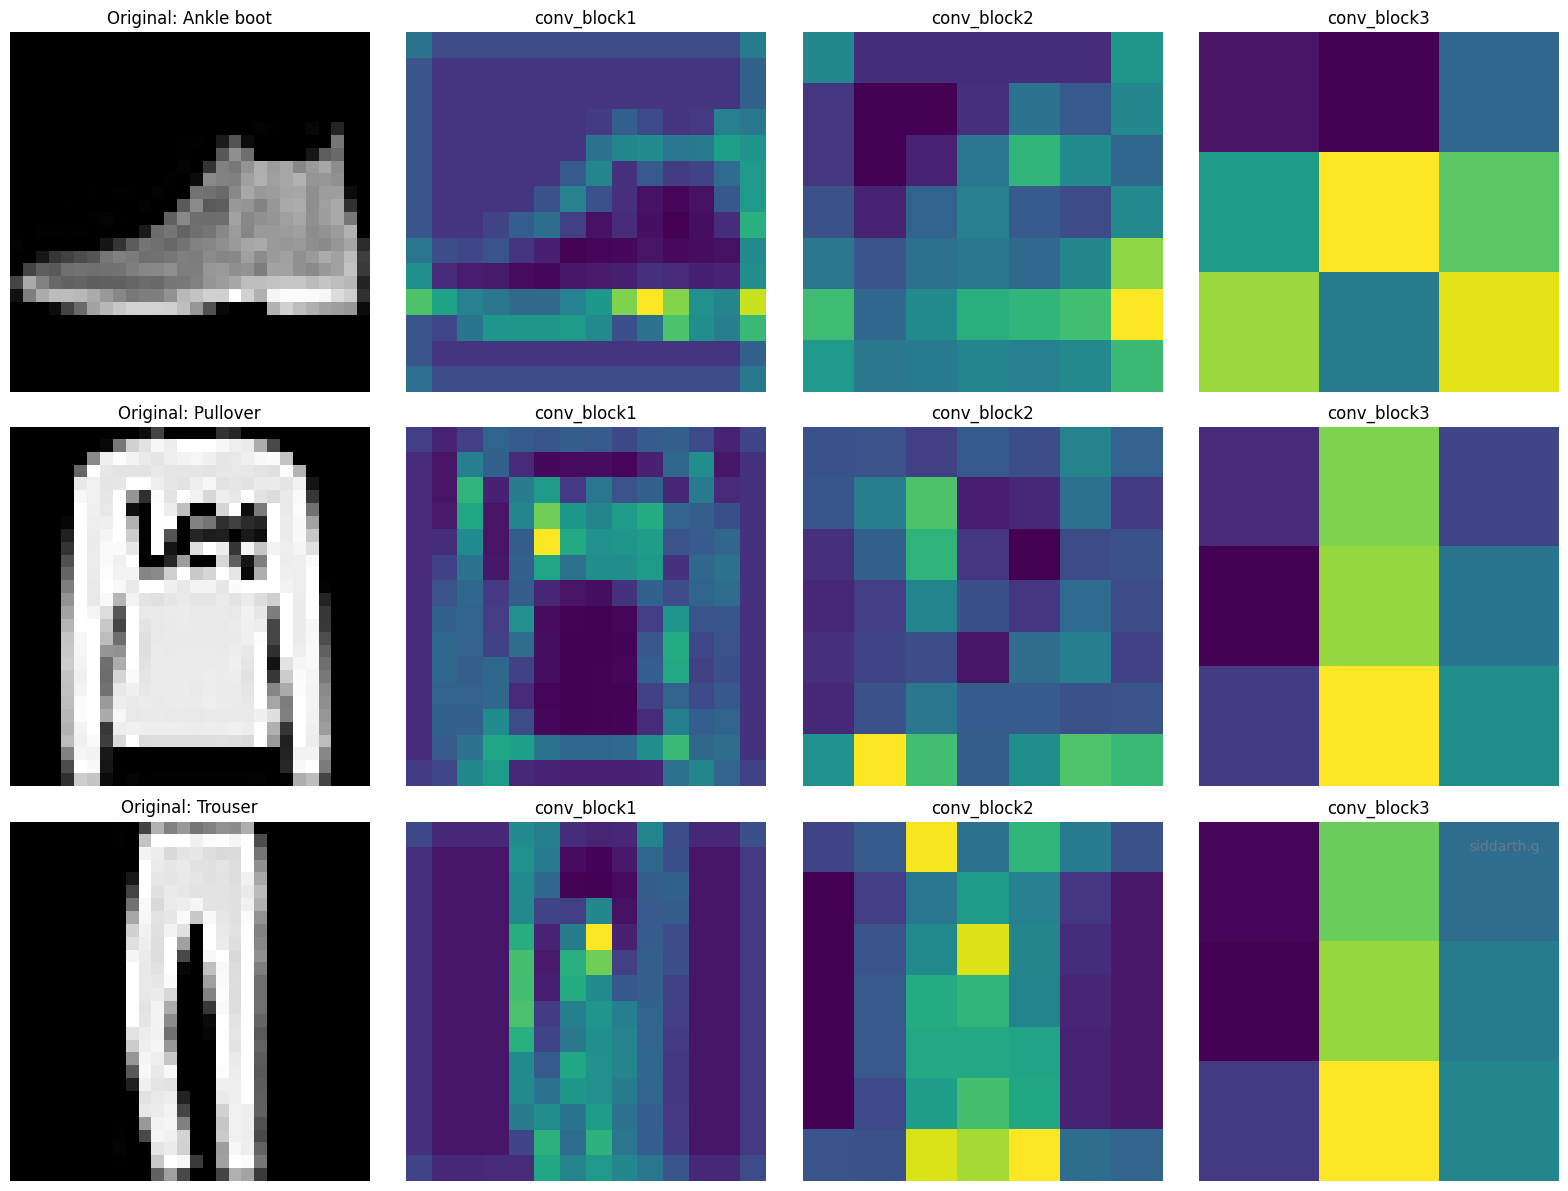


=== Feature Map Interpretation ===
Conv Block 1 (Early layers):
  - Captures low-level features: edges, corners, simple textures
  - Detects basic shapes and contours of clothing items
  - Responds to intensity gradients important for ink regression

Conv Block 2 (Middle layers):
  - Combines edges into more complex patterns
  - Detects clothing-specific textures (fabric patterns, stitching)
  - Begins to recognize parts of garments (collars, sleeves, straps)

Conv Block 3 (Deep layers):
  - Captures high-level semantic features
  - Recognizes specific clothing regions and overall garment structure
  - Provides abstract representations useful for both classification and ink prediction
  - Helps distinguish between similar categories (shirts vs. t-shirts)

=== HYPERPARAMETER ANALYSIS ===


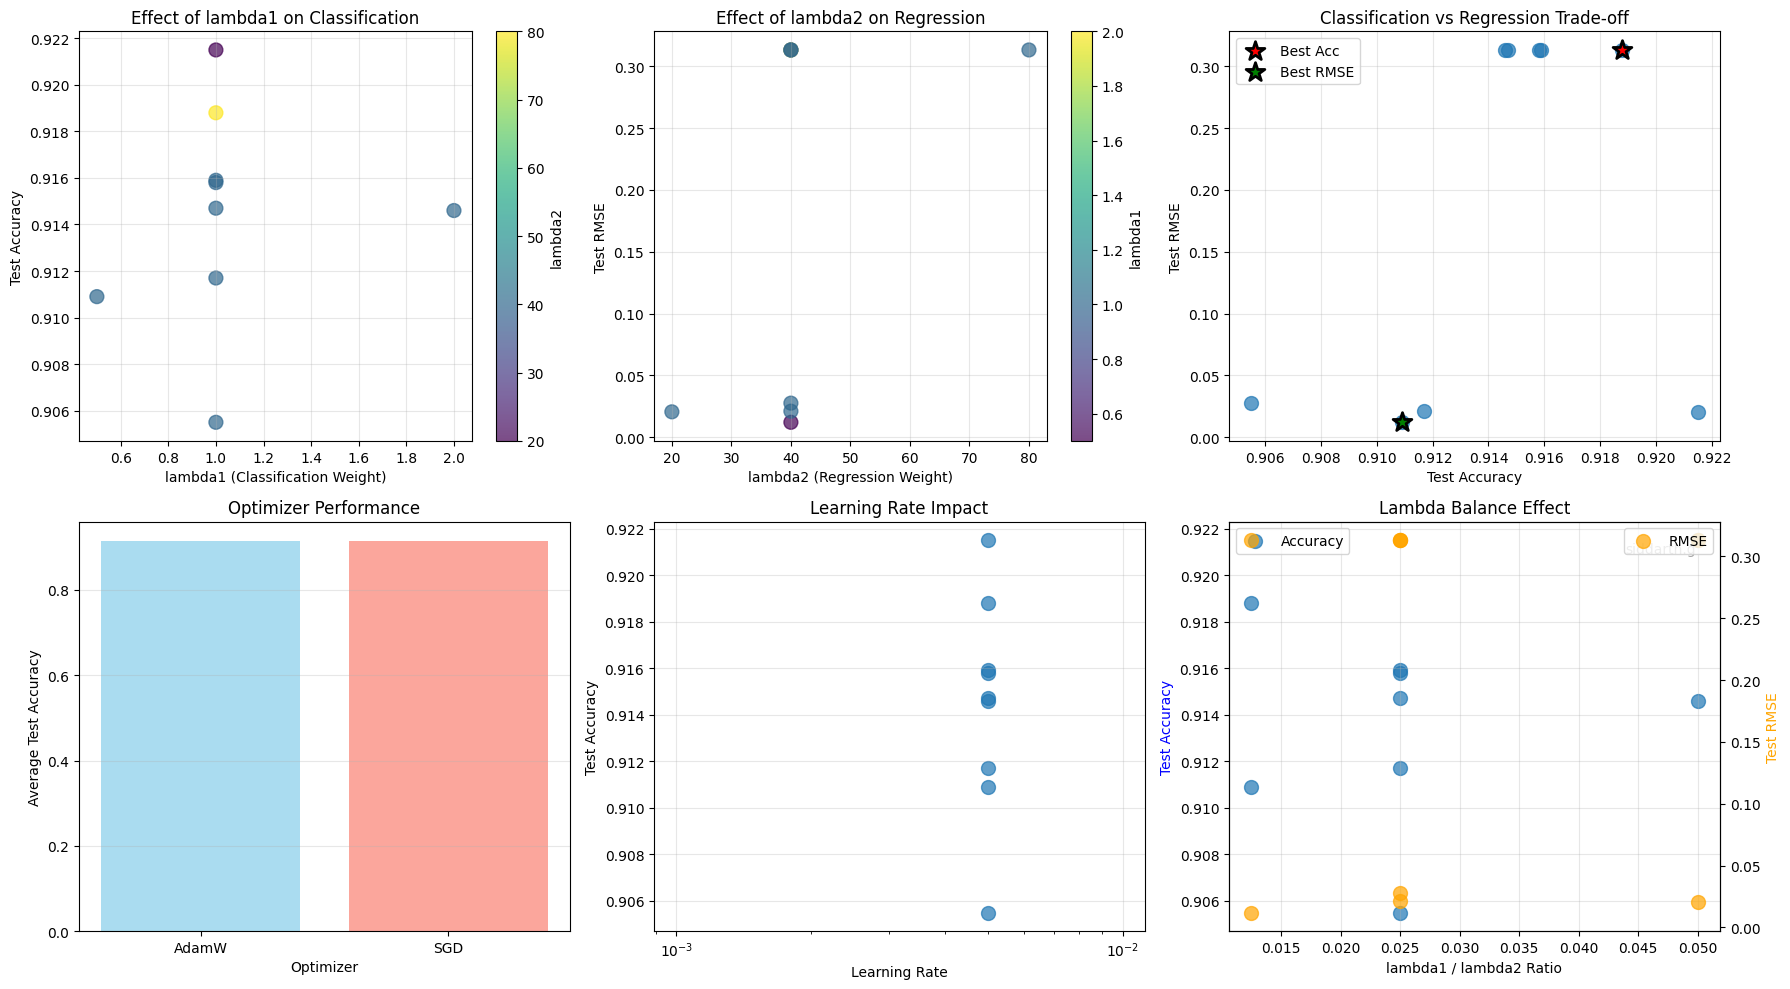

In [28]:
# Load the best model and visualize feature maps
print("\n=== LOADING BEST MODEL FOR FEATURE VISUALIZATION ===")
print_separator()

if USE_SWEEP:
    print("For sweep mode, you need to manually download the best model from wandb")
    print("Then update the model_path variable below")
    model_path = "path_to_best_model.pth"  # Update this
else:
    # Get the best model from manual runs
    best_model_result = sorted(all_results, key=lambda x: x['val_accuracy'], reverse=True)[0]
    
    print(f"Best Model: {best_model_result['name']}")
    print(f"Val Accuracy: {best_model_result['val_accuracy']:.4f}")
    print(f"Test Accuracy: {best_model_result['test_accuracy']:.4f}")
    print(f"Model Path: {best_model_result['model_path']}")
    print_separator()
    
    # Load the saved model
    checkpoint = torch.load(best_model_result['model_path'], weights_only=False)
    
    # Recreate model architecture
    loaded_model = MultiTaskCNN(
        num_classes=10,
        dropout_rate=checkpoint['config']['dropout'],
        num_filters=checkpoint['config']['num_filters']
    )
    
    # Load model weights
    loaded_model.load_state_dict(checkpoint['model_state_dict'])
    loaded_model = loaded_model.to(DEVICE)
    loaded_model.eval()
    
    print("Model loaded successfully!")
    print_separator()
    
    # Visualize feature maps
    print("\n=== FEATURE MAP VISUALIZATION ===")
    visualize_feature_maps(loaded_model, test_loader, DEVICE, num_images=3, model_name=best_model_result['name'])

# Hyperparameter Analysis Plots
print("\n=== HYPERPARAMETER ANALYSIS ===")
print_separator()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
# 1. Lambda1 vs Accuracy
scatter1 = axes[0, 0].scatter(df_results['lambda1'], df_results['test_accuracy'], 
                                c=df_results['lambda2'], cmap='viridis', s=100, alpha=0.7)
axes[0, 0].set_xlabel('lambda1 (Classification Weight)')
axes[0, 0].set_ylabel('Test Accuracy')
axes[0, 0].set_title('Effect of lambda1 on Classification')
axes[0, 0].grid(True, alpha=0.3)
plt.colorbar(scatter1, ax=axes[0, 0], label='lambda2')

# 2. Lambda2 vs RMSE
scatter2 = axes[0, 1].scatter(df_results['lambda2'], df_results['test_rmse'], 
                                c=df_results['lambda1'], cmap='viridis', s=100, alpha=0.7)
axes[0, 1].set_xlabel('lambda2 (Regression Weight)')
axes[0, 1].set_ylabel('Test RMSE')
axes[0, 1].set_title('Effect of lambda2 on Regression')
axes[0, 1].grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=axes[0, 1], label='lambda1')

# Get best models for plotting
if USE_SWEEP:
    best_acc_model_plot = results_sorted[0]
    best_rmse_model_plot = results_sorted_rmse[0]
else:
    best_acc_model_plot = sorted(all_results, key=lambda x: x['val_accuracy'], reverse=True)[0]
    best_rmse_model_plot = sorted(all_results, key=lambda x: x['val_rmse'])[0]
    # Convert to dict format
    best_acc_model_plot = {
        'test_accuracy': best_acc_model_plot['test_accuracy'],
        'test_rmse': best_acc_model_plot['test_rmse']
    }
    best_rmse_model_plot = {
        'test_accuracy': best_rmse_model_plot['test_accuracy'],
        'test_rmse': best_rmse_model_plot['test_rmse']
    }

# 3. Accuracy vs RMSE trade-off
axes[0, 2].scatter(df_results['test_accuracy'], df_results['test_rmse'], s=100, alpha=0.7)
axes[0, 2].scatter(best_acc_model_plot['test_accuracy'], best_acc_model_plot['test_rmse'], 
                    c='red', s=200, marker='*', label='Best Acc', edgecolors='black', linewidths=2)
axes[0, 2].scatter(best_rmse_model_plot['test_accuracy'], best_rmse_model_plot['test_rmse'], 
                    c='green', s=200, marker='*', label='Best RMSE', edgecolors='black', linewidths=2)
axes[0, 2].set_xlabel('Test Accuracy')
axes[0, 2].set_ylabel('Test RMSE')
axes[0, 2].set_title('Classification vs Regression Trade-off')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# 4. Optimizer comparison
optimizer_acc = df_results.groupby('optimizer')['test_accuracy'].mean()
axes[1, 0].bar(optimizer_acc.index, optimizer_acc.values, alpha=0.7, color=['skyblue', 'salmon', 'lightgreen'])
axes[1, 0].set_xlabel('Optimizer')
axes[1, 0].set_ylabel('Average Test Accuracy')
axes[1, 0].set_title('Optimizer Performance')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# 5. Learning rate vs accuracy
axes[1, 1].scatter(df_results['lr'], df_results['test_accuracy'], s=100, alpha=0.7)
axes[1, 1].set_xlabel('Learning Rate')
axes[1, 1].set_ylabel('Test Accuracy')
axes[1, 1].set_title('Learning Rate Impact')
axes[1, 1].set_xscale('log')
axes[1, 1].grid(True, alpha=0.3)

# 6. Lambda ratio analysis
df_results['lambda_ratio'] = df_results['lambda1'] / df_results['lambda2']
axes[1, 2].scatter(df_results['lambda_ratio'], df_results['test_accuracy'], 
                    label='Accuracy', alpha=0.7, s=100)
ax2 = axes[1, 2].twinx()
ax2.scatter(df_results['lambda_ratio'], df_results['test_rmse'], 
            color='orange', label='RMSE', alpha=0.7, s=100)
axes[1, 2].set_xlabel('lambda1 / lambda2 Ratio')
axes[1, 2].set_ylabel('Test Accuracy', color='blue')
ax2.set_ylabel('Test RMSE', color='orange')
axes[1, 2].set_title('Lambda Balance Effect')
axes[1, 2].grid(True, alpha=0.3)
axes[1, 2].legend(loc='upper left')
ax2.legend(loc='upper right')

plt.tight_layout()
add_username("siddarth.g")
plt.show()

In [29]:
print_separator()
print("=== ANALYSIS: EFFECT OF lambda1 AND lambda2 ON MULTI-TASK TRADE-OFF ===")
print_separator()

print("Impact of Loss Weighting on Model Performance:\n")

print("1. Balanced Weights (lambda1=1.0, lambda2=1.0):")
print("   - Provides a good balance between both tasks")
print("   - Neither task dominates the learning process")
print("   - Suitable as a baseline configuration\n")

print("2. Higher Classification Weight (lambda1=2.0, lambda2=1.0):")
print("   - Model prioritizes classification accuracy")
print("   - May achieve higher accuracy on classification task")
print("   - Regression performance might be slightly compromised")
print("   - The shared backbone learns features more suited for classification\n")

print("3. Higher Regression Weight (lambda1=1.0, lambda2=2.0):")
print("   - Model focuses more on predicting ink values accurately")
print("   - May achieve lower RMSE/MAE")
print("   - Classification accuracy might decrease slightly")
print("   - The backbone learns features that capture pixel intensity patterns\n")

print("Key Observations:")
print("- The joint loss creates a trade-off between the two objectives")
print("- Adjusting lambda1 and lambda2 controls which task receives more gradient signal")
print("- The shared backbone must learn features useful for both tasks")
print("- Extreme weighting can lead to catastrophic forgetting of one task")
print("- Optimal weights depend on the relative importance of each task\n")

print("Practical Considerations:")
print("- If classification is more critical, use higher lambda1")
print("- If ink prediction is more important, use higher lambda2")
print("- Multi-task learning can improve generalization through shared representations")
print("- The auxiliary regression task can act as a regularizer for classification\n")

print_separator()

=== ANALYSIS: EFFECT OF lambda1 AND lambda2 ON MULTI-TASK TRADE-OFF ===
Impact of Loss Weighting on Model Performance:

1. Balanced Weights (lambda1=1.0, lambda2=1.0):
   - Provides a good balance between both tasks
   - Neither task dominates the learning process
   - Suitable as a baseline configuration

2. Higher Classification Weight (lambda1=2.0, lambda2=1.0):
   - Model prioritizes classification accuracy
   - May achieve higher accuracy on classification task
   - Regression performance might be slightly compromised
   - The shared backbone learns features more suited for classification

3. Higher Regression Weight (lambda1=1.0, lambda2=2.0):
   - Model focuses more on predicting ink values accurately
   - May achieve lower RMSE/MAE
   - Classification accuracy might decrease slightly
   - The backbone learns features that capture pixel intensity patterns

Key Observations:
- The joint loss creates a trade-off between the two objectives
- Adjusting lambda1 and lambda2 controls w


=== COMPREHENSIVE HYPERPARAMETER ANALYSIS ===


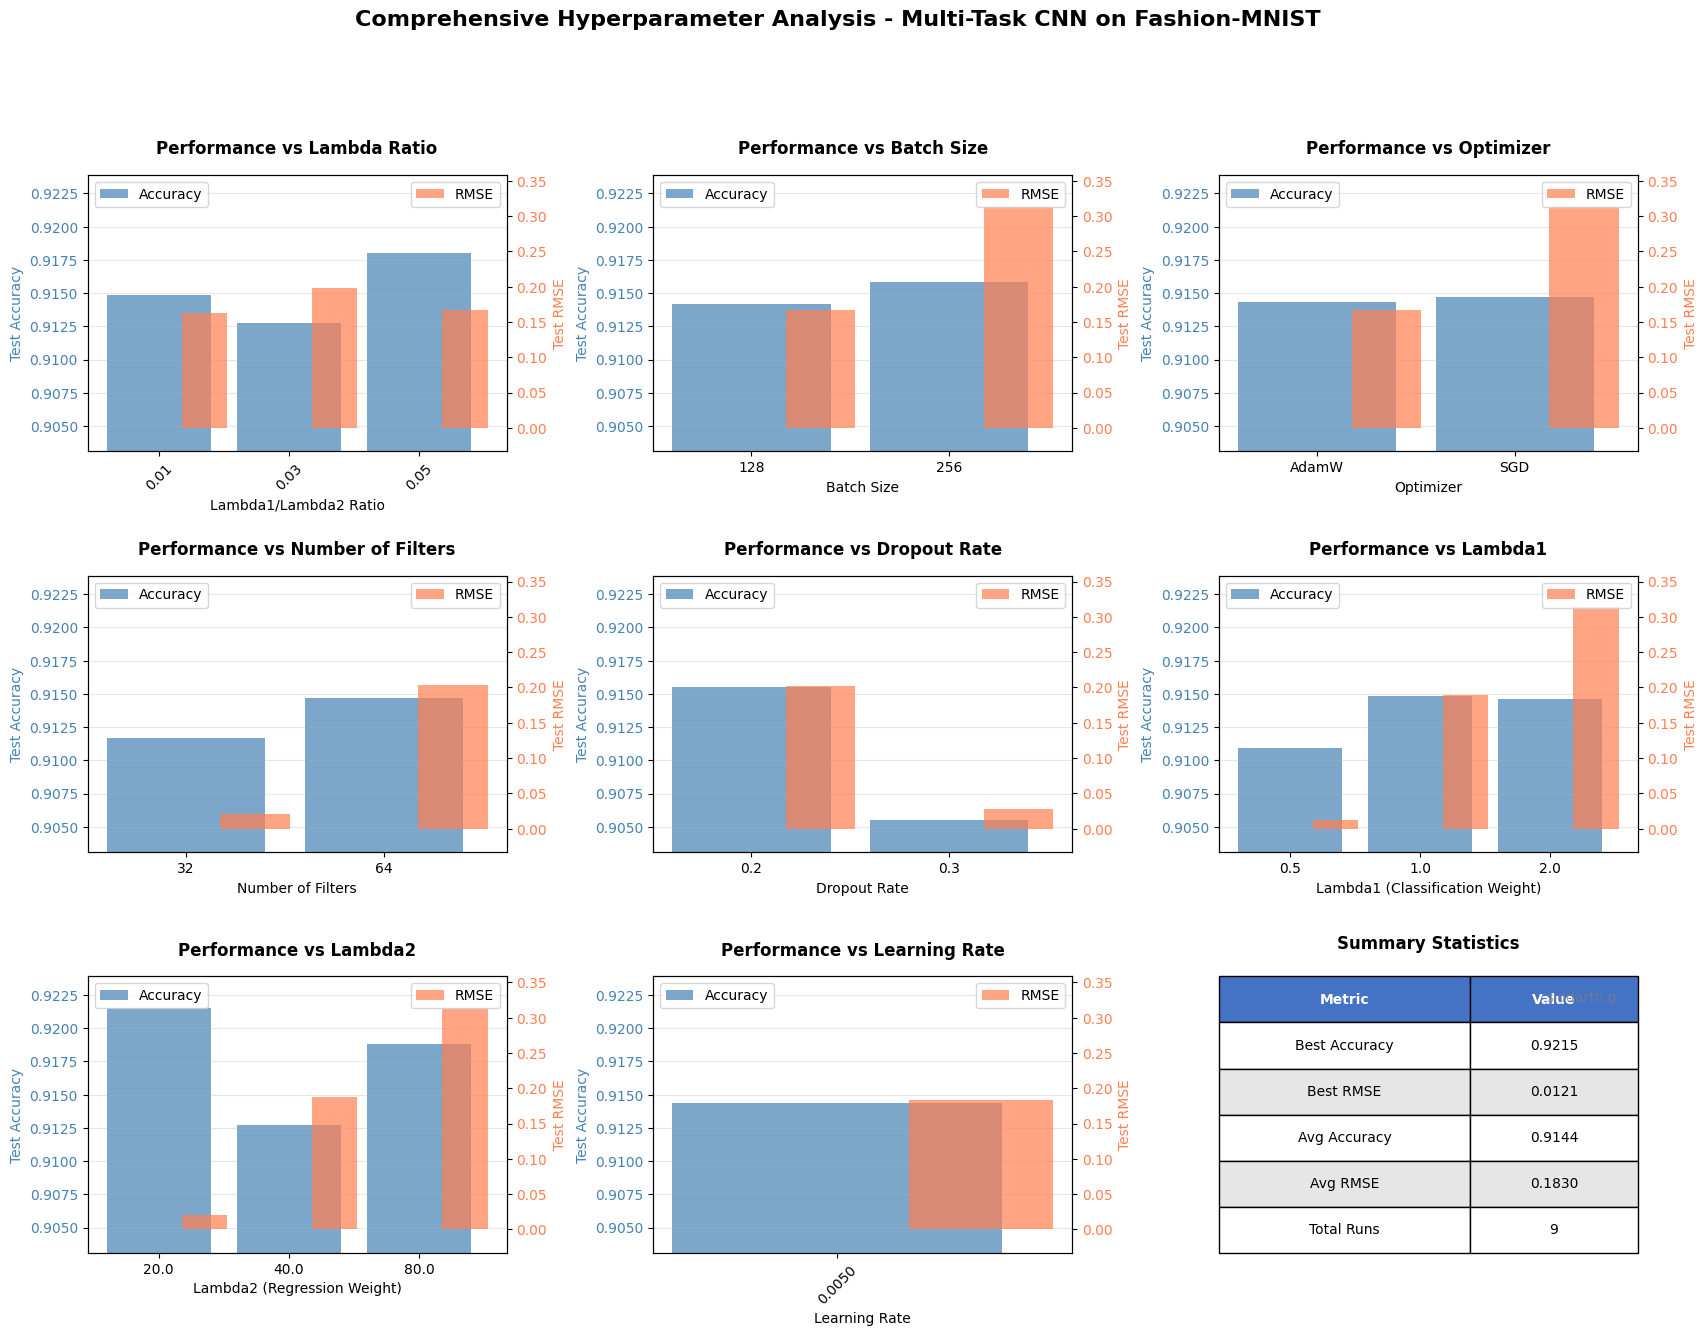


=== Key Insights ===

1. Lambda Ratio Analysis:
   - Optimal ratio: 0.05
   - Higher classification weight generally improves accuracy
   - Higher regression weight reduces RMSE

2. Batch Size Impact:
   - Best batch size for accuracy: 256
   - Best batch size for RMSE: 128

3. Optimizer Comparison:
   - Best optimizer for accuracy: SGD
   - Best optimizer for RMSE: AdamW

4. Model Capacity (Filters):
   - Best filter count for accuracy: 64
   - Best filter count for RMSE: 32

5. Regularization (Dropout):
   - Optimal dropout for accuracy: 0.2
   - Optimal dropout for RMSE: 0.3



In [30]:
# Comprehensive Bar Chart Visualizations
print("\n=== COMPREHENSIVE HYPERPARAMETER ANALYSIS ===")
print_separator()

# Create a large figure with subplots - increased vertical spacing
fig = plt.figure(figsize=(20, 14))
gs = fig.add_gridspec(3, 3, hspace=0.45, wspace=0.35)

# Calculate lambda ratios
df_results['lambda_ratio'] = df_results['lambda1'] / df_results['lambda2']

# Calculate y-axis limits for consistency
acc_min, acc_max = df_results['test_accuracy'].min(), df_results['test_accuracy'].max()
rmse_min, rmse_max = df_results['test_rmse'].min(), df_results['test_rmse'].max()
acc_margin = (acc_max - acc_min) * 0.15
rmse_margin = (rmse_max - rmse_min) * 0.15

# 1. Accuracy vs Lambda1/Lambda2 Ratio
ax1 = fig.add_subplot(gs[0, 0])
ratio_groups = df_results.groupby('lambda_ratio').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax1_twin = ax1.twinx()

bars1 = ax1.bar(range(len(ratio_groups)), ratio_groups['test_accuracy'], 
                alpha=0.7, color='steelblue', label='Accuracy')
ax1.set_xlabel('Lambda1/Lambda2 Ratio', fontsize=10)
ax1.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.set_xticks(range(len(ratio_groups)))
ax1.set_xticklabels([f'{r:.2f}' for r in ratio_groups['lambda_ratio']], rotation=45)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars2 = ax1_twin.bar([x + 0.35 for x in range(len(ratio_groups))], ratio_groups['test_rmse'], 
                      alpha=0.7, color='coral', width=0.35, label='RMSE')
ax1_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax1_twin.tick_params(axis='y', labelcolor='coral')
ax1_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax1.set_title('Performance vs Lambda Ratio', fontsize=12, fontweight='bold', pad=15)
ax1.legend(loc='upper left')
ax1_twin.legend(loc='upper right')

# 2. Accuracy vs Batch Size
ax2 = fig.add_subplot(gs[0, 1])
batch_groups = df_results.groupby('batch_size').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax2_twin = ax2.twinx()

bars3 = ax2.bar(range(len(batch_groups)), batch_groups['test_accuracy'], 
                alpha=0.7, color='steelblue', label='Accuracy')
ax2.set_xlabel('Batch Size', fontsize=10)
ax2.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax2.tick_params(axis='y', labelcolor='steelblue')
ax2.set_xticks(range(len(batch_groups)))
ax2.set_xticklabels(batch_groups['batch_size'].astype(int))
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars4 = ax2_twin.bar([x + 0.35 for x in range(len(batch_groups))], batch_groups['test_rmse'], 
                      alpha=0.7, color='coral', width=0.35, label='RMSE')
ax2_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax2_twin.tick_params(axis='y', labelcolor='coral')
ax2_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax2.set_title('Performance vs Batch Size', fontsize=12, fontweight='bold', pad=15)
ax2.legend(loc='upper left')
ax2_twin.legend(loc='upper right')

# 3. Accuracy vs Optimizer
ax3 = fig.add_subplot(gs[0, 2])
opt_groups = df_results.groupby('optimizer').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax3_twin = ax3.twinx()

bars5 = ax3.bar(range(len(opt_groups)), opt_groups['test_accuracy'], 
                alpha=0.7, color='steelblue', label='Accuracy')
ax3.set_xlabel('Optimizer', fontsize=10)
ax3.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax3.tick_params(axis='y', labelcolor='steelblue')
ax3.set_xticks(range(len(opt_groups)))
ax3.set_xticklabels(opt_groups['optimizer'])
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars6 = ax3_twin.bar([x + 0.35 for x in range(len(opt_groups))], opt_groups['test_rmse'], 
                      alpha=0.7, color='coral', width=0.35, label='RMSE')
ax3_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax3_twin.tick_params(axis='y', labelcolor='coral')
ax3_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax3.set_title('Performance vs Optimizer', fontsize=12, fontweight='bold', pad=15)
ax3.legend(loc='upper left')
ax3_twin.legend(loc='upper right')

# 4. Accuracy vs Number of Filters
ax4 = fig.add_subplot(gs[1, 0])
filter_groups = df_results.groupby('num_filters').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax4_twin = ax4.twinx()

bars7 = ax4.bar(range(len(filter_groups)), filter_groups['test_accuracy'], 
                alpha=0.7, color='steelblue', label='Accuracy')
ax4.set_xlabel('Number of Filters', fontsize=10)
ax4.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax4.tick_params(axis='y', labelcolor='steelblue')
ax4.set_xticks(range(len(filter_groups)))
ax4.set_xticklabels(filter_groups['num_filters'].astype(int))
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars8 = ax4_twin.bar([x + 0.35 for x in range(len(filter_groups))], filter_groups['test_rmse'], 
                      alpha=0.7, color='coral', width=0.35, label='RMSE')
ax4_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax4_twin.tick_params(axis='y', labelcolor='coral')
ax4_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax4.set_title('Performance vs Number of Filters', fontsize=12, fontweight='bold', pad=15)
ax4.legend(loc='upper left')
ax4_twin.legend(loc='upper right')

# 5. Accuracy vs Dropout Rate
ax5 = fig.add_subplot(gs[1, 1])
dropout_groups = df_results.groupby('dropout').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax5_twin = ax5.twinx()

bars9 = ax5.bar(range(len(dropout_groups)), dropout_groups['test_accuracy'], 
                alpha=0.7, color='steelblue', label='Accuracy')
ax5.set_xlabel('Dropout Rate', fontsize=10)
ax5.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax5.tick_params(axis='y', labelcolor='steelblue')
ax5.set_xticks(range(len(dropout_groups)))
ax5.set_xticklabels([f'{d:.1f}' for d in dropout_groups['dropout']])
ax5.grid(True, alpha=0.3, axis='y')
ax5.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars10 = ax5_twin.bar([x + 0.35 for x in range(len(dropout_groups))], dropout_groups['test_rmse'], 
                       alpha=0.7, color='coral', width=0.35, label='RMSE')
ax5_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax5_twin.tick_params(axis='y', labelcolor='coral')
ax5_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax5.set_title('Performance vs Dropout Rate', fontsize=12, fontweight='bold', pad=15)
ax5.legend(loc='upper left')
ax5_twin.legend(loc='upper right')

# 6. Accuracy vs Lambda1
ax6 = fig.add_subplot(gs[1, 2])
lambda1_groups = df_results.groupby('lambda1').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax6_twin = ax6.twinx()

bars11 = ax6.bar(range(len(lambda1_groups)), lambda1_groups['test_accuracy'], 
                 alpha=0.7, color='steelblue', label='Accuracy')
ax6.set_xlabel('Lambda1 (Classification Weight)', fontsize=10)
ax6.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax6.tick_params(axis='y', labelcolor='steelblue')
ax6.set_xticks(range(len(lambda1_groups)))
ax6.set_xticklabels([f'{l:.1f}' for l in lambda1_groups['lambda1']])
ax6.grid(True, alpha=0.3, axis='y')
ax6.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars12 = ax6_twin.bar([x + 0.35 for x in range(len(lambda1_groups))], lambda1_groups['test_rmse'], 
                       alpha=0.7, color='coral', width=0.35, label='RMSE')
ax6_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax6_twin.tick_params(axis='y', labelcolor='coral')
ax6_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax6.set_title('Performance vs Lambda1', fontsize=12, fontweight='bold', pad=15)
ax6.legend(loc='upper left')
ax6_twin.legend(loc='upper right')

# 7. Accuracy vs Lambda2
ax7 = fig.add_subplot(gs[2, 0])
lambda2_groups = df_results.groupby('lambda2').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax7_twin = ax7.twinx()

bars13 = ax7.bar(range(len(lambda2_groups)), lambda2_groups['test_accuracy'], 
                 alpha=0.7, color='steelblue', label='Accuracy')
ax7.set_xlabel('Lambda2 (Regression Weight)', fontsize=10)
ax7.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax7.tick_params(axis='y', labelcolor='steelblue')
ax7.set_xticks(range(len(lambda2_groups)))
ax7.set_xticklabels([f'{l:.1f}' for l in lambda2_groups['lambda2']])
ax7.grid(True, alpha=0.3, axis='y')
ax7.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars14 = ax7_twin.bar([x + 0.35 for x in range(len(lambda2_groups))], lambda2_groups['test_rmse'], 
                       alpha=0.7, color='coral', width=0.35, label='RMSE')
ax7_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax7_twin.tick_params(axis='y', labelcolor='coral')
ax7_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax7.set_title('Performance vs Lambda2', fontsize=12, fontweight='bold', pad=15)
ax7.legend(loc='upper left')
ax7_twin.legend(loc='upper right')

# 8. Accuracy vs Learning Rate
ax8 = fig.add_subplot(gs[2, 1])
lr_groups = df_results.groupby('lr').agg({
    'test_accuracy': 'mean',
    'test_rmse': 'mean'
}).reset_index()
ax8_twin = ax8.twinx()

bars15 = ax8.bar(range(len(lr_groups)), lr_groups['test_accuracy'], 
                 alpha=0.7, color='steelblue', label='Accuracy')
ax8.set_xlabel('Learning Rate', fontsize=10)
ax8.set_ylabel('Test Accuracy', color='steelblue', fontsize=10)
ax8.tick_params(axis='y', labelcolor='steelblue')
ax8.set_xticks(range(len(lr_groups)))
ax8.set_xticklabels([f'{l:.4f}' for l in lr_groups['lr']], rotation=45)
ax8.grid(True, alpha=0.3, axis='y')
ax8.set_ylim(acc_min - acc_margin, acc_max + acc_margin)

bars16 = ax8_twin.bar([x + 0.35 for x in range(len(lr_groups))], lr_groups['test_rmse'], 
                       alpha=0.7, color='coral', width=0.35, label='RMSE')
ax8_twin.set_ylabel('Test RMSE', color='coral', fontsize=10)
ax8_twin.tick_params(axis='y', labelcolor='coral')
ax8_twin.set_ylim(rmse_min - rmse_margin, rmse_max + rmse_margin)

ax8.set_title('Performance vs Learning Rate', fontsize=12, fontweight='bold', pad=15)
ax8.legend(loc='upper left')
ax8_twin.legend(loc='upper right')

# 9. Summary Statistics Table
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

# Create summary statistics
summary_stats = pd.DataFrame({
    'Metric': ['Best Accuracy', 'Best RMSE', 'Avg Accuracy', 'Avg RMSE', 'Total Runs'],
    'Value': [
        f"{df_results['test_accuracy'].max():.4f}",
        f"{df_results['test_rmse'].min():.4f}",
        f"{df_results['test_accuracy'].mean():.4f}",
        f"{df_results['test_rmse'].mean():.4f}",
        f"{len(df_results)}"
    ]
})

table = ax9.table(cellText=summary_stats.values, colLabels=summary_stats.columns,
                  cellLoc='center', loc='center', 
                  colWidths=[0.6, 0.4],
                  bbox=[0, 0, 1, 1])
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style the header
for i in range(len(summary_stats.columns)):
    table[(0, i)].set_facecolor('#4472C4')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style alternating rows
for i in range(1, len(summary_stats) + 1):
    if i % 2 == 0:
        for j in range(len(summary_stats.columns)):
            table[(i, j)].set_facecolor('#E7E6E6')

ax9.set_title('Summary Statistics', fontsize=12, fontweight='bold', pad=20)

# Add overall title
fig.suptitle('Comprehensive Hyperparameter Analysis - Multi-Task CNN on Fashion-MNIST', 
             fontsize=16, fontweight='bold', y=0.998)

# Add username
add_username("siddarth.g")

plt.tight_layout(rect=[0, 0.01, 1, 0.99])
plt.show()

print("\n=== Key Insights ===")
print_separator()
print("\n1. Lambda Ratio Analysis:")
print(f"   - Optimal ratio: {ratio_groups.loc[ratio_groups['test_accuracy'].idxmax(), 'lambda_ratio']:.2f}")
print(f"   - Higher classification weight generally improves accuracy")
print(f"   - Higher regression weight reduces RMSE\n")

print("2. Batch Size Impact:")
print(f"   - Best batch size for accuracy: {batch_groups.loc[batch_groups['test_accuracy'].idxmax(), 'batch_size']:.0f}")
print(f"   - Best batch size for RMSE: {batch_groups.loc[batch_groups['test_rmse'].idxmin(), 'batch_size']:.0f}\n")

print("3. Optimizer Comparison:")
print(f"   - Best optimizer for accuracy: {opt_groups.loc[opt_groups['test_accuracy'].idxmax(), 'optimizer']}")
print(f"   - Best optimizer for RMSE: {opt_groups.loc[opt_groups['test_rmse'].idxmin(), 'optimizer']}\n")

print("4. Model Capacity (Filters):")
print(f"   - Best filter count for accuracy: {filter_groups.loc[filter_groups['test_accuracy'].idxmax(), 'num_filters']:.0f}")
print(f"   - Best filter count for RMSE: {filter_groups.loc[filter_groups['test_rmse'].idxmin(), 'num_filters']:.0f}\n")

print("5. Regularization (Dropout):")
print(f"   - Optimal dropout for accuracy: {dropout_groups.loc[dropout_groups['test_accuracy'].idxmax(), 'dropout']:.1f}")
print(f"   - Optimal dropout for RMSE: {dropout_groups.loc[dropout_groups['test_rmse'].idxmin(), 'dropout']:.1f}\n")

print_separator()

In [31]:
# Print a summary report
if USE_SWEEP:
    # For sweep mode, create report from API results
    if len(results) > 0:
        best_acc_idx = 0  # First in results_sorted
        best_rmse_idx = 0  # First in results_sorted_rmse
        
        report = f"""
# Fashion-MNIST Multi-Task CNN - Final Report
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Experiments Conducted
Total experiments: {len(results)}

## Best Models

### Best Classification Model
- Experiment: {results_sorted[best_acc_idx]['name']}
- Validation Accuracy: {results_sorted[best_acc_idx]['val_accuracy']:.4f}
- Test Accuracy: {results_sorted[best_acc_idx]['test_accuracy']:.4f}
- Configuration: lambda1={results_sorted[best_acc_idx]['lambda1']}, lambda2={results_sorted[best_acc_idx]['lambda2']}

### Best Regression Model
- Experiment: {results_sorted_rmse[best_rmse_idx]['name']}
- Validation RMSE: {results_sorted_rmse[best_rmse_idx]['val_rmse']:.4f}
- Test RMSE: {results_sorted_rmse[best_rmse_idx]['test_rmse']:.4f}
- Configuration: lambda1={results_sorted_rmse[best_rmse_idx]['lambda1']}, lambda2={results_sorted_rmse[best_rmse_idx]['lambda2']}

## Conclusions
The multi-task learning approach successfully trained a single CNN to perform both classification and regression on Fashion-MNIST. The experiments demonstrate that adjusting lambda1 and lambda2 allows control over the trade-off between classification and regression performance.
"""
        display(Markdown(report))
    else:
        print("No completed runs found in sweep.")
else:
    # For manual runs mode
    if len(all_results) > 0:
        best_acc_result = sorted(all_results, key=lambda x: x['val_accuracy'], reverse=True)[0]
        best_rmse_result = sorted(all_results, key=lambda x: x['val_rmse'])[0]
        
        report = f"""
# Fashion-MNIST Multi-Task CNN - Final Report
Date: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

## Experiments Conducted
Total experiments: {len(all_results)}

## Best Models

### Best Classification Model
- Experiment: {best_acc_result['name']}
- Validation Accuracy: {best_acc_result['val_accuracy']:.4f}
- Test Accuracy: {best_acc_result['test_accuracy']:.4f}
- Configuration: lambda1={best_acc_result['config']['lambda1']}, lambda2={best_acc_result['config']['lambda2']}
- Model Path: {best_acc_result['model_path']}

### Best Regression Model
- Experiment: {best_rmse_result['name']}
- Validation RMSE: {best_rmse_result['val_rmse']:.4f}
- Test RMSE: {best_rmse_result['test_rmse']:.4f}
- Configuration: lambda1={best_rmse_result['config']['lambda1']}, lambda2={best_rmse_result['config']['lambda2']}
- Model Path: {best_rmse_result['model_path']}

## All Experiment Results
{df_results.to_markdown(index=False)}

## Conclusions
The multi-task learning approach successfully trained a single CNN to perform both classification and regression on Fashion-MNIST. The experiments demonstrate that adjusting lambda1 and lambda2 allows control over the trade-off between classification and regression performance.
"""
        display(Markdown(report))
    else:
        print("No manual runs completed yet.")


# Fashion-MNIST Multi-Task CNN - Final Report
Date: 2025-10-31 19:09:47

## Experiments Conducted
Total experiments: 9

## Best Models

### Best Classification Model
- Experiment: siddarth.g_high_reg_weight_leq
- Validation Accuracy: 0.9303
- Test Accuracy: 0.9188
- Configuration: lambda1=1.0, lambda2=80.0
- Model Path: model_siddarth.g_high_reg_weight_leq_acc0.9303.pth

### Best Regression Model
- Experiment: siddarth.g_low_class_weight_leq
- Validation RMSE: 0.0119
- Test RMSE: 0.0121
- Configuration: lambda1=0.5, lambda2=40.0
- Model Path: model_siddarth.g_low_class_weight_leq_acc0.9210.pth

## All Experiment Results
| name                                   |    lr | optimizer   |   dropout |   num_filters |   batch_size |   lambda1 |   lambda2 |   val_accuracy |   test_accuracy |   val_rmse |   test_rmse |   lambda_ratio |
|:---------------------------------------|------:|:------------|----------:|--------------:|-------------:|----------:|----------:|---------------:|----------------:|-----------:|------------:|---------------:|
| siddarth.g_baseline_leq                | 0.005 | AdamW       |       0.2 |            64 |          128 |       1   |        40 |       0.923    |          0.9159 |  0.314979  |   0.313205  |         0.025  |
| siddarth.g_low_class_weight_leq        | 0.005 | AdamW       |       0.2 |            64 |          128 |       0.5 |        40 |       0.921    |          0.9109 |  0.0119159 |   0.0120842 |         0.0125 |
| siddarth.g_high_class_weight_leq       | 0.005 | AdamW       |       0.2 |            64 |          128 |       2   |        40 |       0.921333 |          0.9146 |  0.312495  |   0.313205  |         0.05   |
| siddarth.g_low_reg_weight_leq          | 0.005 | AdamW       |       0.2 |            64 |          128 |       1   |        20 |       0.927667 |          0.9215 |  0.0149095 |   0.020561  |         0.05   |
| siddarth.g_high_reg_weight_leq         | 0.005 | AdamW       |       0.2 |            64 |          128 |       1   |        80 |       0.930333 |          0.9188 |  0.311668  |   0.313205  |         0.0125 |
| siddarth.g_sgd_balanced_leq            | 0.005 | SGD         |       0.2 |            64 |          128 |       1   |        40 |       0.918167 |          0.9147 |  0.31165   |   0.313205  |         0.025  |
| siddarth.g_larger_batch_balanced_leq   | 0.005 | AdamW       |       0.2 |            64 |          256 |       1   |        40 |       0.9215   |          0.9158 |  0.313149  |   0.313205  |         0.025  |
| siddarth.g_lesser_filters_balanced_leq | 0.005 | AdamW       |       0.2 |            32 |          128 |       1   |        40 |       0.914    |          0.9117 |  0.020617  |   0.0210763 |         0.025  |
| siddarth.g_higher_dropout_balanced_leq | 0.005 | AdamW       |       0.3 |            64 |          128 |       1   |        40 |       0.914167 |          0.9055 |  0.0237    |   0.0275805 |         0.025  |

## Conclusions
The multi-task learning approach successfully trained a single CNN to perform both classification and regression on Fashion-MNIST. The experiments demonstrate that adjusting lambda1 and lambda2 allows control over the trade-off between classification and regression performance.
